# Prepare Environment

In [1]:
# Check for local CSV; if missing, download from Firebase using pyasebase/pyrebase
import os
import pandas as pd
from pybaseball import pitching_stats
import numpy as np

csv_path = "./data/pitching_stats.csv"

if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    data = pd.read_csv(csv_path)
else:
    print(f"{csv_path} not found — attempting to download using pybaseball.")
    qual = 10
    start_season = 2015
    end_season = 2025
    data = pitching_stats(start_season=start_season, end_season=end_season, qual=qual)
    data.to_csv('./data/pitching_stats.csv', index=False)

Found ./data/pitching_stats.csv, reading into DataFrame.


In [2]:
from src.mvt_pitcher_model import MVTPitcherDataset, MVTPitcherPredictionDataSet, MVTPitcherModel

# Prepare Training Data

In [3]:
# Process data for 3D tensor - organized by player-season combination
import torch
import numpy as np
import pandas as pd

# Select relevant columns
features = [
    'G',
    'GS',
    'IP',
    'TBF',
    'HR',
    'BB',
    'SO',
    'GB',
    'GB%',
    'FB',
    'FB%',
    'LD',
    'Pitches',
    'CSW%',
    'FIP',
]

target = 'WAR'

# Qualification parameter: minimum IP in target season to include in training set
min_qual_ip = 50  # Set to > 0 to filter by innings pitched (e.g., 50 for minimum 50 IP)
nlookbacks = 5

mvt_dataset = MVTPitcherDataset(
    features=features,
    data = data,
    target=target,
    nlookbacks=5,
    min_qual_ip=50,
)

X = mvt_dataset.sequences
y_features = mvt_dataset.targets_features
y_war = mvt_dataset.ult_target
metadata_df = mvt_dataset.metadata_df

print(f"Tensor shape: {X.shape}")
print(f"Features target shape: {y_features.shape}")
print(f"WAR target shape: {y_war.shape}")
print(f"Metadata rows: {len(metadata_df)}")
print(f"Qualification filter: min_qual_ip = {min_qual_ip}")
print(f"\nFirst few metadata entries:")
print(metadata_df.head())
print(f"\nSample sequence for entry 0:\n{X[0]}")
print(f"Corresponding features: {y_features[0]}")
print(f"Corresponding WAR target: {y_war[0]:.4f}")


Tensor shape: torch.Size([2804, 5, 15])
Features target shape: torch.Size([2804, 15])
WAR target shape: torch.Size([2804])
Metadata rows: 2804
Qualification filter: min_qual_ip = 50

First few metadata entries:
                         current_season  target_ip
player_id target_season                           
18        2016                     2015       53.2
375       2016                     2015      191.2
          2017                     2016      143.0
          2018                     2017      146.1
404       2016                     2015      179.2

Sample sequence for entry 0:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00,

# Prepare Prediction Data

In [4]:
pred_season = 2025

mvt_pred_dataset = MVTPitcherPredictionDataSet(
    features=features,
    data = data,
    nlookbacks=5,
    pred_season = pred_season
)

X_pred = mvt_pred_dataset.pred_sequences
pred_metadata_df = mvt_pred_dataset.pred_metadata

print(f"Prediction set size: {X_pred.shape}")
print(f"Number of players with {pred_season} data: {len(pred_metadata_df)}")
print(f"\nFirst few prediction metadata entries:")
print(pred_metadata_df.head())


Prediction set size: torch.Size([657, 5, 15])
Number of players with 2025 data: 657

First few prediction metadata entries:
           prediction_season
player_id                   
2036                    2025
3096                    2025
3137                    2025
3237                    2025
3548                    2025


# Define Model using Transformer

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np


def prepare_data(X, y_features, y_war, features_list, test_size=0.2, batch_size=32, store_scaler_path='./scaler.pkl'):
    """
    Prepare data for training: normalize, split, and create DataLoaders.
    Stores the scaler for later use on prediction data.
    
    Args:
        X: Tensor of shape (num_sequences, seq_len, num_features)
        y_features: Tensor of shape (num_sequences, num_features) - predicted feature values
        y_war: Tensor of shape (num_sequences,) - WAR targets
        features_list: List of feature names for normalization tracking
        test_size: Proportion of data for validation
        batch_size: Batch size for DataLoaders
        store_scaler_path: Path to save the fitted scaler
    
    Returns:
        train_loader, val_loader, scaler, feature_stats, y_war_mean, y_war_std, device
        where feature_stats is a dict of {'name': (mean, std)} for each feature
    """
    import pickle
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Normalize features across all sequences
    X_np = X.cpu().numpy()  # (num_sequences, seq_len, num_features)
    num_sequences, seq_len, num_features = X_np.shape
    
    # Reshape for scaling: (num_sequences * seq_len, num_features)
    X_reshaped = X_np.reshape(-1, num_features)
    
    # Fit scaler on training data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reshaped)
    
    # Save scaler
    with open(store_scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {store_scaler_path}")
    
    # Reshape back to original dimensions
    X_scaled = X_scaled.reshape(num_sequences, seq_len, num_features)
    X_scaled = torch.tensor(X_scaled, dtype=torch.float32)
    
    # Normalize feature targets
    y_features_np = y_features.cpu().numpy() if isinstance(y_features, torch.Tensor) else y_features
    
    feature_stats = {}
    y_features_normalized_list = []
    
    for i, feature_name in enumerate(features_list):
        feature_values = y_features_np[:, i]
        feature_mean = np.mean(feature_values)
        feature_std = np.std(feature_values)
        feature_stats[feature_name] = (feature_mean, feature_std)
        
        normalized = (feature_values - feature_mean) / (feature_std + 1e-8)
        y_features_normalized_list.append(normalized)
    
    y_features_normalized = np.array(y_features_normalized_list).T  # (num_sequences, num_features)
    y_features_normalized = torch.tensor(y_features_normalized, dtype=torch.float32)
    
    # Normalize WAR targets
    y_war_np = y_war.cpu().numpy() if isinstance(y_war, torch.Tensor) else y_war
    y_war_mean = np.mean(y_war_np)
    y_war_std = np.std(y_war_np)
    y_war_normalized = (y_war_np - y_war_mean) / (y_war_std + 1e-8)
    y_war_normalized = torch.tensor(y_war_normalized, dtype=torch.float32)
    
    # Train-validation split
    X_train, X_val, y_features_train, y_features_val, y_war_train, y_war_val = train_test_split(
        X_scaled, y_features_normalized, y_war_normalized, test_size=test_size, random_state=42
    )
    
    # Create datasets with all targets
    train_dataset = TensorDataset(
        X_train.to(device), 
        y_features_train.to(device),
        y_war_train.to(device)
    )
    val_dataset = TensorDataset(
        X_val.to(device), 
        y_features_val.to(device),
        y_war_val.to(device)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, scaler, feature_stats, torch.tensor(y_war_mean), torch.tensor(y_war_std), device


def train_model(model, train_loader, val_loader, features_list, num_epochs=100, learning_rate=1e-3, 
                patience=15, device='cpu', feature_weight=0.3, war_weight=0.7):
    """
    Train transformer model with all feature outputs and WAR with early stopping and learning rate scheduler.
    WAR loss is weighted higher since WAR depends on all predicted features.
    
    Args:
        model: MultiVariateTransformer model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        features_list: List of feature names being predicted
        num_epochs: Maximum number of epochs
        learning_rate: Initial learning rate
        patience: Number of epochs without improvement before early stopping
        device: Device to train on
        feature_weight: Weight for each feature loss
        war_weight: Weight for WAR loss
    
    Returns:
        model, train_losses, val_losses, best_epoch
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0
    num_features = len(features_list)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_features_batch, y_war_batch in train_loader:
            optimizer.zero_grad()
            feature_preds, war_pred = model(X_batch)
            
            # Combined loss: weighted sum of feature losses and WAR loss
            # Equal weight for each feature combined
            features_loss = criterion(feature_preds, y_features_batch)
            war_loss = criterion(war_pred, y_war_batch)
            loss = feature_weight * features_loss + war_weight * war_loss
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_features_batch, y_war_batch in val_loader:
                feature_preds, war_pred = model(X_batch)
                
                features_loss = criterion(feature_preds, y_features_batch)
                war_loss = criterion(war_pred, y_war_batch)
                loss = feature_weight * features_loss + war_weight * war_loss
                
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            torch.save(model.state_dict(), './results/v3/best_model.pt')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load('./results/v3/best_model.pt'))
            break
    
    return model, train_losses, val_losses, best_epoch


def plot_losses(train_losses, val_losses, title='Training and Validation Losses'):
    """
    Plot training and validation losses.
    
    Args:
        train_losses: List of training losses
        val_losses: List of validation losses
        title: Plot title
    """
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Initialize model with num_features parameter
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = MVTPitcherModel(
    input_dim=len(features),
    num_features=len(features),
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    seq_len=nlookbacks
).to(device)

print(f"Model initialized on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Predicting {len(features)} features + WAR")
print(model)


Model initialized on device: mps
Total parameters: 1,915,344
Predicting 15 features + WAR
MVTPitcherModel(
  (input_projection): Linear(in_features=15, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (feature_heads): ModuleList(
    (0-14): 15 x Sequential(
      (0): Linear(in_features=320, out_features=2

Scaler saved to ./scaler.pkl

Feature Statistics (Mean, Std):
  G: (40.9804, 19.5831)
  GS: (13.0175, 12.4798)
  IP: (100.8460, 47.8547)
  TBF: (425.4797, 198.9155)
  HR: (13.0210, 7.9600)
  BB: (33.6359, 16.1163)
  SO: (97.4733, 48.9106)
  GB: (124.4743, 66.0471)
  GB%: (0.4345, 0.0791)
  FB: (103.4579, 55.0626)
  FB%: (0.3629, 0.0780)
  LD: (58.3770, 30.6129)
  Pitches: (1655.3341, 767.0007)
  CSW%: (0.2787, 0.0271)
  FIP: (4.0277, 0.9217)

WAR Statistics:
  Mean: 1.3077, Std: 1.3699
Epoch 10/100, Train Loss: 0.613609, Val Loss: 0.686520
Epoch 20/100, Train Loss: 0.542536, Val Loss: 0.642092
Early stopping at epoch 25
Best epoch: 5


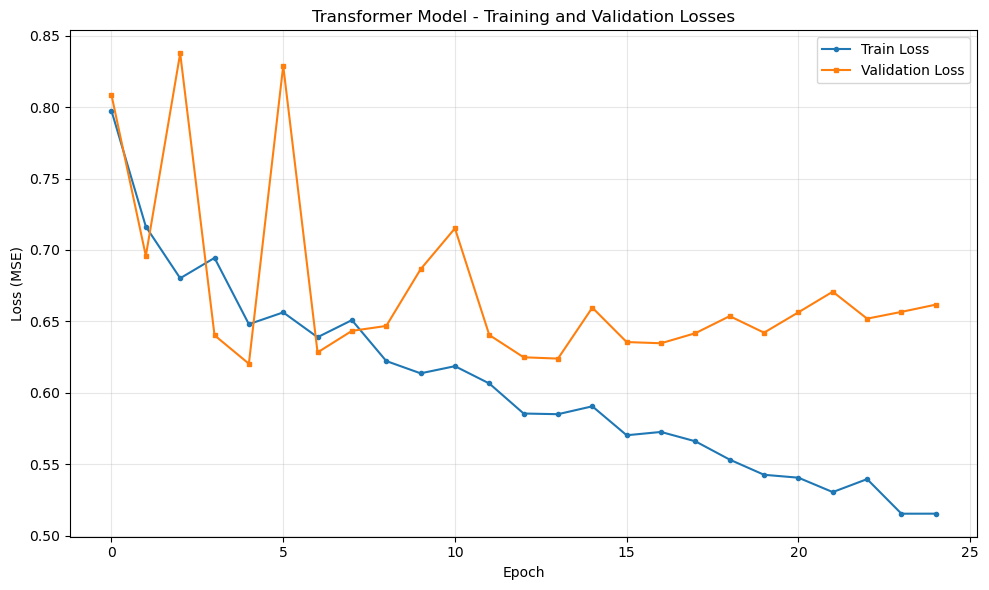


Validation Metrics (normalized):
  War - MSE: 0.654008, R²: 0.4214

Validation Metrics (denormalized) - Mean Absolute Error:
  WAR - MAE: 0.8485

Per-Feature Validation Metrics (denormalized):
  G - MAE: 8.8772, R²: 0.6322
  GS - MAE: 5.4164, R²: 0.6628
  IP - MAE: 24.9797, R²: 0.5158
  TBF - MAE: 103.0965, R²: 0.5137
  HR - MAE: 4.3055, R²: 0.4445
  BB - MAE: 9.4991, R²: 0.4138
  SO - MAE: 26.7117, R²: 0.5101
  GB - MAE: 34.5306, R²: 0.5277
  GB% - MAE: 0.0416, R²: 0.5369
  FB - MAE: 28.5330, R²: 0.5078
  FB% - MAE: 0.0401, R²: 0.5623
  LD - MAE: 16.4029, R²: 0.4769
  Pitches - MAE: 400.1612, R²: 0.5202
  CSW% - MAE: 0.0185, R²: 0.2866
  FIP - MAE: 0.6247, R²: 0.2098


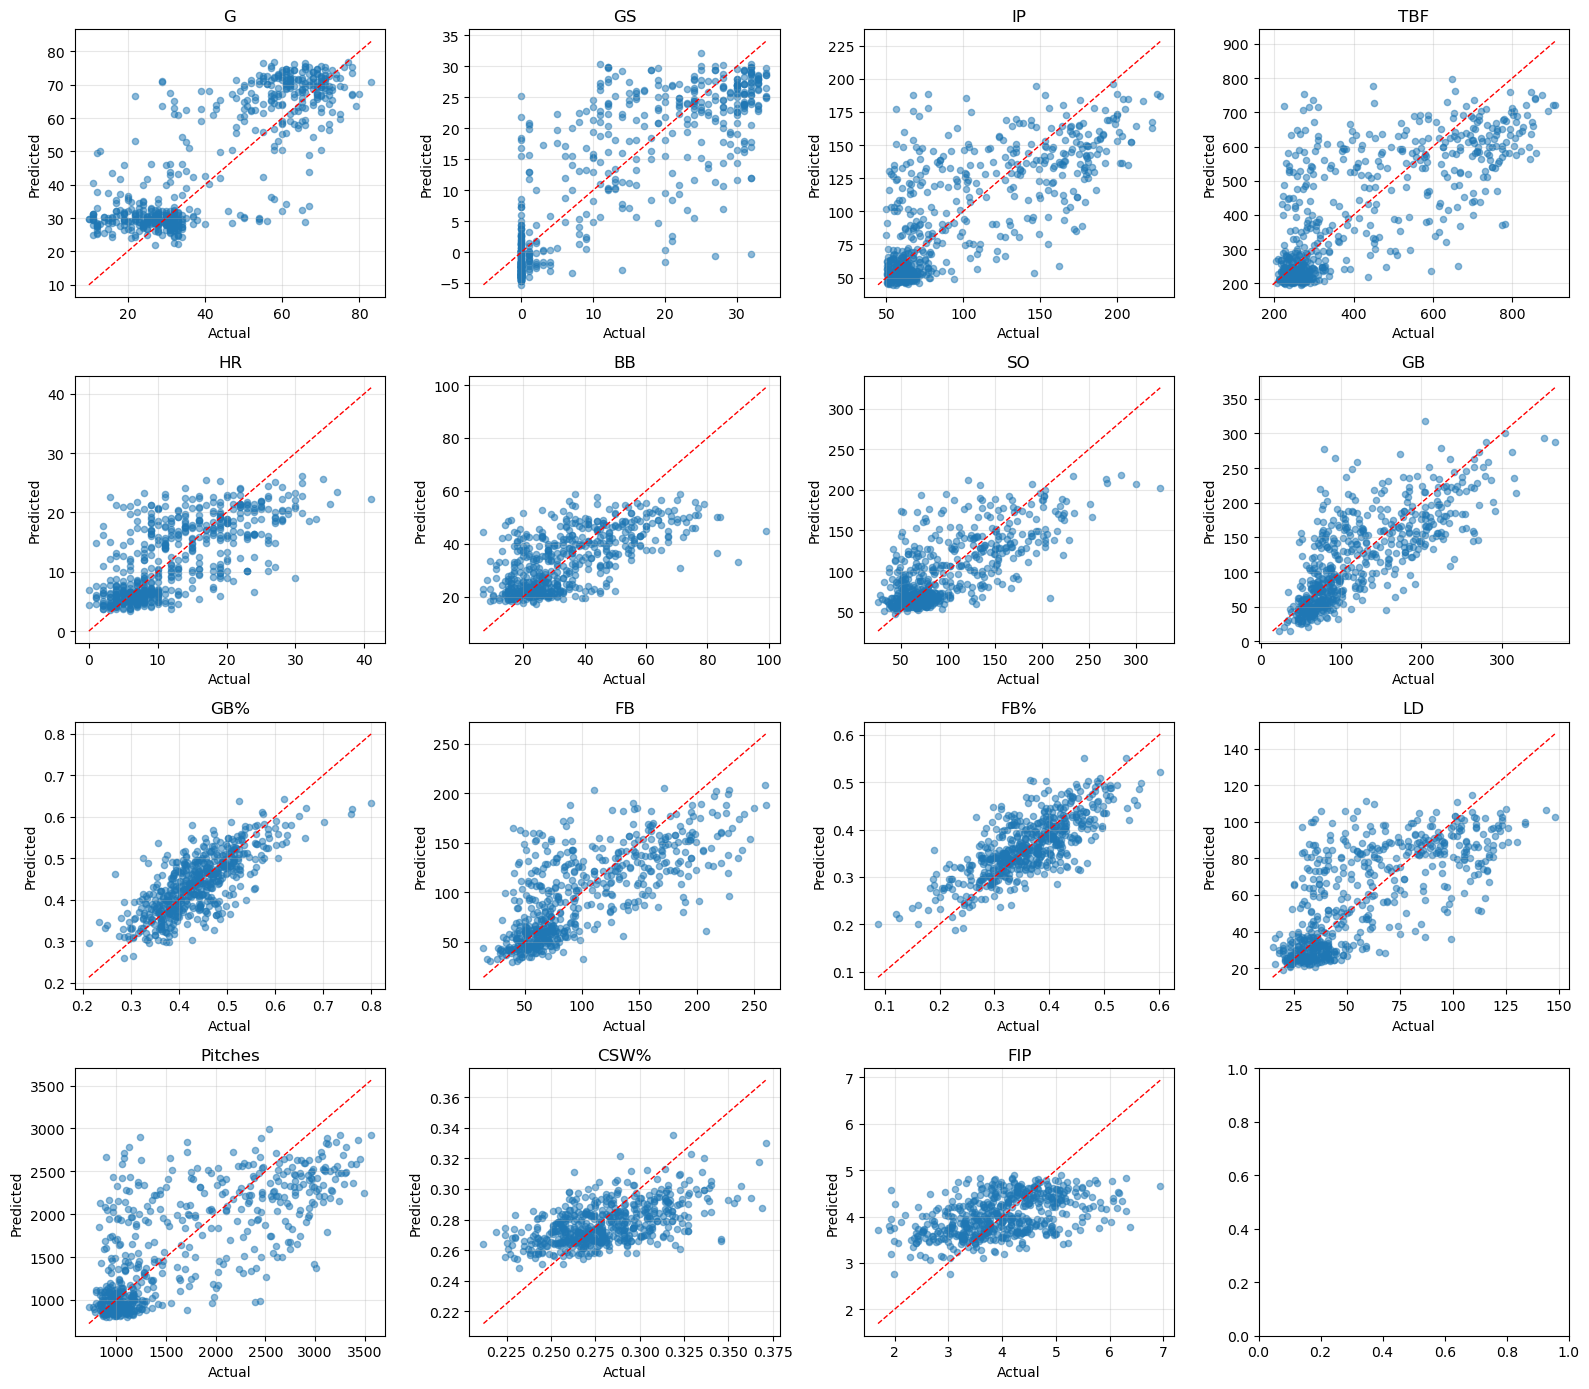

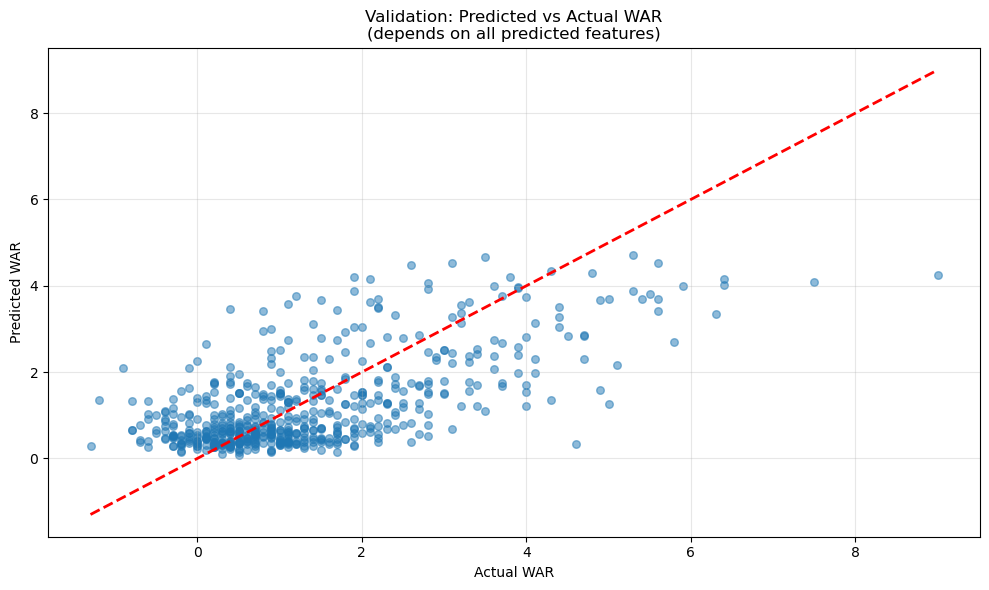


Model and scaler saved for predictions


In [9]:
# Prepare data and save scaler
train_loader, val_loader, scaler, feature_stats, y_war_mean, y_war_std, device = prepare_data(
    X, y_features, y_war, features, batch_size=32
)

print(f"\nFeature Statistics (Mean, Std):")
for feature_name, (mean, std) in feature_stats.items():
    print(f"  {feature_name}: ({mean:.4f}, {std:.4f})")

print(f"\nWAR Statistics:")
print(f"  Mean: {y_war_mean.item():.4f}, Std: {y_war_std.item():.4f}")

# Train model with early stopping
model, train_losses, val_losses, best_epoch = train_model(
    model, train_loader, val_loader, features,
    num_epochs=100, 
    learning_rate=1e-3, 
    patience=20, 
    device=device,
    feature_weight=0.3,  # Weight for feature predictions
    war_weight=0.7       # Higher weight for WAR (which depends on all predicted features)
)

print(f"Best epoch: {best_epoch + 1}")

# Plot losses
plot_losses(train_losses, val_losses, title='Transformer Model - Training and Validation Losses')

# Make predictions on validation set
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model.eval()
feature_predictions = []
war_predictions = []
feature_actuals = []
war_actuals = []

with torch.no_grad():
    for inputs, targets_features, targets_war in val_loader:
        feature_preds, war_pred = model(inputs)
        feature_predictions.extend(feature_preds.cpu().numpy())
        war_predictions.extend(war_pred.cpu().numpy().flatten())
        feature_actuals.extend(targets_features.cpu().numpy())
        war_actuals.extend(targets_war.cpu().numpy())

feature_predictions = np.array(feature_predictions)  # (num_val, num_features)
war_predictions = np.array(war_predictions)  # (num_val,)
feature_actuals = np.array(feature_actuals)  # (num_val, num_features)
war_actuals = np.array(war_actuals)  # (num_val,)

# Denormalize predictions and actuals for interpretability
feature_predictions_denorm = np.zeros_like(feature_predictions)
feature_actuals_denorm = np.zeros_like(feature_actuals)

for i, feature_name in enumerate(features):
    mean, std = feature_stats[feature_name]
    feature_predictions_denorm[:, i] = feature_predictions[:, i] * std + mean
    feature_actuals_denorm[:, i] = feature_actuals[:, i] * std + mean

war_predictions_denorm = war_predictions * y_war_std.item() + y_war_mean.item()
war_actuals_denorm = war_actuals * y_war_std.item() + y_war_mean.item()

# Calculate metrics
print(f"\nValidation Metrics (normalized):")
print(f"  War - MSE: {mean_squared_error(war_actuals, war_predictions):.6f}, R²: {r2_score(war_actuals, war_predictions):.4f}")

print(f"\nValidation Metrics (denormalized) - Mean Absolute Error:")
war_mae = mean_absolute_error(war_actuals_denorm, war_predictions_denorm)
print(f"  WAR - MAE: {war_mae:.4f}")

# Per-feature metrics
print(f"\nPer-Feature Validation Metrics (denormalized):")
for i, feature_name in enumerate(features):
    mae = mean_absolute_error(feature_actuals_denorm[:, i], feature_predictions_denorm[:, i])
    r2 = r2_score(feature_actuals[:, i], feature_predictions[:, i])
    print(f"  {feature_name} - MAE: {mae:.4f}, R²: {r2:.4f}")

# Plot predictions vs actuals for select features
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i in range(min(16, len(features))):
    ax = axes[i]
    ax.scatter(feature_actuals_denorm[:, i], feature_predictions_denorm[:, i], alpha=0.5, s=20)
    min_val = min(feature_actuals_denorm[:, i].min(), feature_predictions_denorm[:, i].min())
    max_val = max(feature_actuals_denorm[:, i].max(), feature_predictions_denorm[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{features[i]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot WAR predictions vs actuals
plt.figure(figsize=(10, 6))
plt.scatter(war_actuals_denorm, war_predictions_denorm, alpha=0.5, s=30)
plt.plot([min(war_actuals_denorm), max(war_actuals_denorm)], 
         [min(war_actuals_denorm), max(war_actuals_denorm)], 'r--', lw=2)
plt.xlabel('Actual WAR')
plt.ylabel('Predicted WAR')
plt.title('Validation: Predicted vs Actual WAR\n(depends on all predicted features)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel and scaler saved for predictions")


PREDICTING 2026 VALUES FOR 2025 SEASON DATA

2026 Predictions for 657 players

Top 20 predicted WAR leaders for 2026:
     player_id  predicted_IP_2026  predicted_CSW%_2026  predicted_war_2026
640      33677         179.748596             0.303246            4.642756
365      22267         170.669861             0.307138            4.511264
305      20778         190.200943             0.296899            4.432794
494      27463         169.089645             0.301627            4.352782
643      33825         176.167740             0.299020            4.328220
456      25880         176.042618             0.295693            4.136468
199      17995         177.641068             0.297498            4.085229
33       10603         148.292023             0.310589            3.977463
59       12768         172.921417             0.293003            3.880206
29       10310         153.631409             0.303370            3.845744
84       13743         173.823837             0.290604   

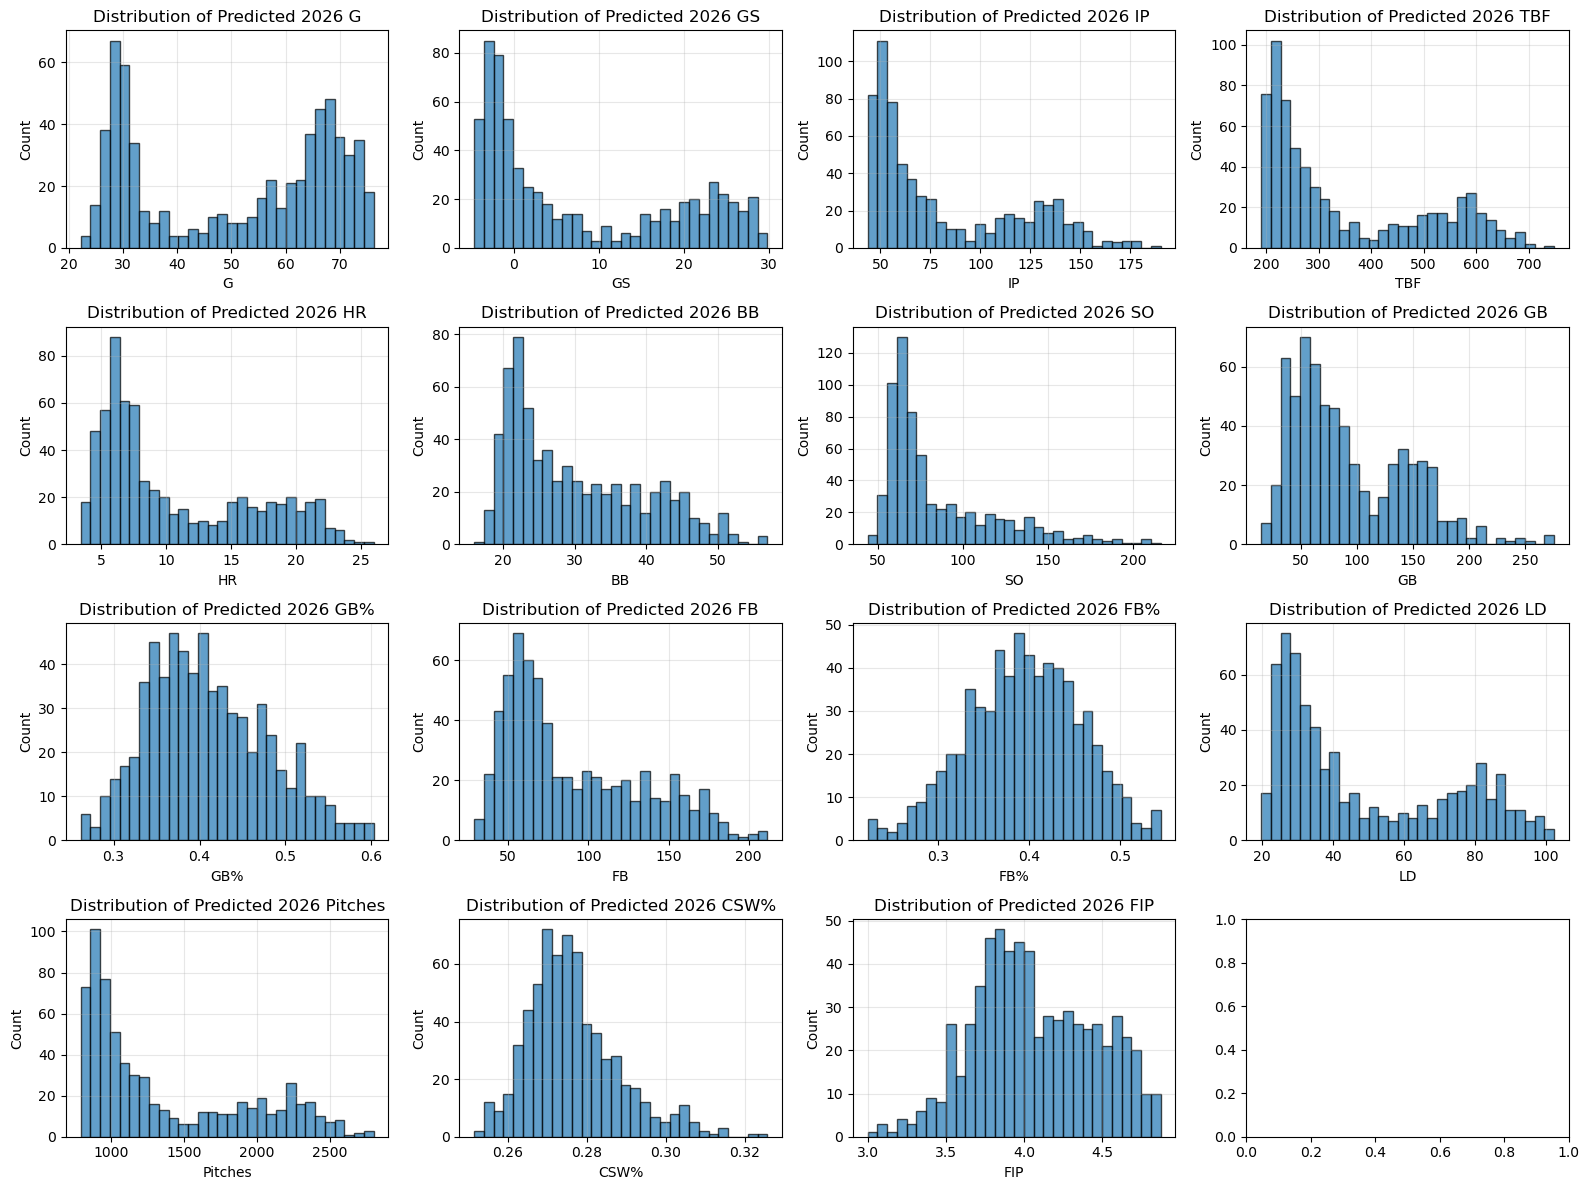

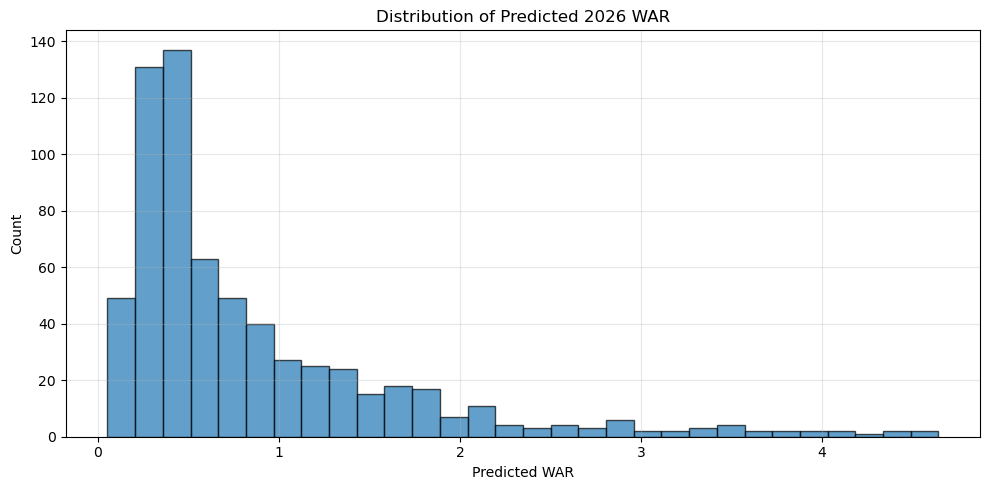

In [10]:
# Predict 2026 WAR using 2025 data
print("="*60)
print("PREDICTING 2026 VALUES FOR 2025 SEASON DATA")
print("="*60)

# Prepare prediction data with scaler normalization
X_pred_np = X_pred.cpu().numpy()
num_pred_sequences, pred_seq_len, pred_num_features = X_pred_np.shape

# Reshape for scaling
X_pred_reshaped = X_pred_np.reshape(-1, pred_num_features)

# Apply the stored scaler
X_pred_scaled = scaler.transform(X_pred_reshaped)
X_pred_scaled = X_pred_scaled.reshape(num_pred_sequences, pred_seq_len, pred_num_features)
X_pred_scaled = torch.tensor(X_pred_scaled, dtype=torch.float32).to(device)

# Make predictions
model.eval()
feature_preds_2026 = []
war_preds_2026 = []

with torch.no_grad():
    for i in range(0, X_pred_scaled.shape[0], 32):  # Process in batches
        batch_end = min(i + 32, X_pred_scaled.shape[0])
        X_batch = X_pred_scaled[i:batch_end]
        feature_pred, war_pred = model(X_batch)
        feature_preds_2026.extend(feature_pred.cpu().numpy())
        war_preds_2026.extend(war_pred.cpu().numpy().flatten())

feature_preds_2026 = np.array(feature_preds_2026)  # (num_players, num_features)
war_preds_2026 = np.array(war_preds_2026)  # (num_players,)

# Denormalize all predictions
feature_preds_2026_denorm = np.zeros_like(feature_preds_2026)
for i, feature_name in enumerate(features):
    mean, std = feature_stats[feature_name]
    feature_preds_2026_denorm[:, i] = feature_preds_2026[:, i] * std + mean

war_preds_2026_denorm = war_preds_2026 * y_war_std.item() + y_war_mean.item()

# Create results dataframe with all predicted features
results_df = pred_metadata_df.copy()
for i, feature_name in enumerate(features):
    results_df[f'predicted_{feature_name}_2026'] = feature_preds_2026_denorm[:, i]
results_df['predicted_war_2026'] = war_preds_2026_denorm

# Reset index to make player_id a column for better readability
results_df = results_df.reset_index()

print(f"\n2026 Predictions for {len(results_df)} players")
print(f"\nTop 20 predicted WAR leaders for 2026:")
display_cols = ['player_id', 'predicted_IP_2026', 'predicted_CSW%_2026', 'predicted_war_2026']
print(results_df.nlargest(20, 'predicted_war_2026')[display_cols])

print(f"\nPrediction Statistics:")
for i, feature_name in enumerate(features):
    print(f"  {feature_name}: mean={feature_preds_2026_denorm[:, i].mean():.4f}, min={feature_preds_2026_denorm[:, i].min():.4f}, max={feature_preds_2026_denorm[:, i].max():.4f}")
print(f"  WAR: mean={war_preds_2026_denorm.mean():.4f}, min={war_preds_2026_denorm.min():.4f}, max={war_preds_2026_denorm.max():.4f}")

# Save predictions to CSV
results_df.to_csv('./results/v3/2026_war_predictions.csv', index=False)
print(f"\nPredictions saved to ./results/v3/2026_war_predictions.csv")

# Plot distributions of predicted 2026 features
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(min(16, len(features))):
    ax = axes[i]
    ax.hist(feature_preds_2026_denorm[:, i], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(features[i])
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of Predicted 2026 {features[i]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot WAR distribution
plt.figure(figsize=(10, 5))
plt.hist(war_preds_2026_denorm, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Predicted WAR')
plt.ylabel('Count')
plt.title('Distribution of Predicted 2026 WAR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
pd.set_option('display.max_rows', 100)
csv_path = "./results/v3/2026_war_predictions.csv"
if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    results_df = pd.read_csv(csv_path)

data_2025 = data[data['Season'] == 2025]
results_with_name = results_df.merge(data_2025[['IDfg','Name',]], left_on=['player_id'], right_on=['IDfg'], how='left')

Found ./results/v3/2026_war_predictions.csv, reading into DataFrame.


In [12]:
results_with_name.sort_values('predicted_war_2026', ascending=False).head(100)[['Name', 'IDfg', 'predicted_war_2026', ]]

,Name,IDfg,predicted_war_2026
640,Paul Skenes,33677,4.642756
365,Tarik Skubal,22267,4.511264
305,Cristopher Sanchez,20778,4.432794
494,Garrett Crochet,27463,4.352782
643,Yoshinobu Yamamoto,33825,4.328220
456,Hunter Brown,25880,4.136468
199,Logan Webb,17995,4.085229
33,Chris Sale,10603,3.977463
59,Sonny Gray,12768,3.880206
29,Zack Wheeler,10310,3.845744
